# WFS and GeoJSON API with GeoPandas

In this notebook you will learn how to consume geospatial data from web services and load it in Python with `geopandas`, using schools in Aragon as a real case study.

## Objectives

- Understand the difference between a **WFS** service and a **GeoJSON API**.
- Load remote geospatial layers into a `GeoDataFrame`.
- Explore, visualize, and filter spatial data using a real education dataset.
- Export a selection to GeoJSON for reuse.


## 1) Key Concepts

### WFS (Web Feature Service) [url](https://es.wikipedia.org/wiki/Web_Feature_Service)
- OGC standard for querying **vector features** (points, lines, polygons).
- It usually allows filtering by attributes, spatial extent, and output format.
- Very common in institutional spatial data infrastructures.

### GeoJSON API [url](https://es.wikipedia.org/wiki/GeoJSON)
- Web API that directly returns objects in **GeoJSON** format.
- It is often simpler to consume from Python and front-end web applications.
- It does not always follow the OGC standard, but it is very practical.

> In practice, both approaches let you bring geometry + attributes into a `GeoDataFrame`.


In [57]:
import geopandas as gpd
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (8, 6)
plt.rcParams['axes.grid'] = True

## 2) Example A: Load data from a GeoJSON API

We will use an Open Data Aragon endpoint with information about education centers.

> Note: the service may return different types of centers. In the analysis, we will specifically filter public schools.


In [58]:
geojson_url = "https://opendata.aragon.es/GA_OD_Core/download?view_id=167&formato=json"

gdf_geojson = gpd.read_file(geojson_url)

# The service declares EPSG:4326, but the coordinates are in UTM zone 30N.
# Assign the correct CRS before reprojecting or combining with other layers.
gdf_geojson = gdf_geojson.set_crs(epsg=25830, allow_override=True)

gdf_geojson.head()

,objectid,idcentrorc,nombre_cen,tipo_centr,naturaleza,localidad,direccion,codpostal,telefono,mail,...,web,coordx,coordy,xcen,ycen,srs,refpar,longitud,latitud,geometry
0,5266,22010876,C.P. María Moliner,Colegio Público,Público,Fraga,C/ Valle de Pineta s/n,22520,974 47 10 54,cpfragaiii@educa.aragon.es,...,https://ceipmariamolinerfraga.wordpress.com/,778172,4602434,778171.00,4602434.00,25830,7607601BG7070N,0.33393894,41.52523162,POINT (778171 4602434)
1,5464,50019792,C.P. María Zambrano,Colegio Público,Público,Zaragoza,"Avenida de la Policía Local, 4",50021,976 56 85 14,ceipmariazambrano@educa.aragon.es,...,ceipmariazambrano.catedu.es,676837,4609567,676837.84,4609567.90,25830,6997401XM7069H,-0.87305947,41.68937072,POINT (676837.84 4609567.9)
2,4509,50701050,Centro Aragonés de Lenguas Extranjeras para la...,Centros de Innovación y Formación Educativa,Público,Zaragoza,"CL. EUGENIO LUCAS, S/N",50018,976506628,centrolenguas@aragon.es,...,NaN,677007,4617474,677007.33,4617474.42,25830,7074503XM7177C,-0.87305947,41.68937072,POINT (677007 4617474)
3,5070,50017503,C. Océano Atlántico,Centro Privado de Formación Profesional Especí...,Privado,Zaragoza,"Avda. Ranillas, 1, edificio 3D",50018,976 10 64 51,info@oceanoatlantico.org,...,www.oceanoatlantico.org,674744,4615232,674744.74,4615232.52,25830,7146201XM7174E,-0.90088145,41.66969467,POINT (674744.74 4615232.52)
4,4617,50009373,C.P. José Camón Aznar,Colegio Público,Público,Zaragoza,"Avda.de Navarra,nº 141",50017,976 32 91 02,cpjcazaragoza@educa.aragon.es,...,ceipcamonaznar.catedu.es,673425,4613789,673425.20,4613789.27,25830,,-0.91714116,41.65699198,POINT (673425.2 4613789.27)


In [59]:
print("CRS:", gdf_geojson.crs)
print("Number of features:", len(gdf_geojson))
print("Main columns:", ["nombre_cen", "tipo_centr", "naturaleza", "localidad", "geometry"])

# Quick view of key fields
gdf_geojson[["nombre_cen", "tipo_centr", "naturaleza", "localidad", "geometry"]].head()

CRS: EPSG:25830
Number of features: 896
Main columns: ['nombre_cen', 'tipo_centr', 'naturaleza', 'localidad', 'geometry']


,nombre_cen,tipo_centr,naturaleza,localidad,geometry
0,C.P. María Moliner,Colegio Público,Público,Fraga,POINT (778171 4602434)
1,C.P. María Zambrano,Colegio Público,Público,Zaragoza,POINT (676837.84 4609567.9)
2,Centro Aragonés de Lenguas Extranjeras para la...,Centros de Innovación y Formación Educativa,Público,Zaragoza,POINT (677007 4617474)
3,C. Océano Atlántico,Centro Privado de Formación Profesional Especí...,Privado,Zaragoza,POINT (674744.74 4615232.52)
4,C.P. José Camón Aznar,Colegio Público,Público,Zaragoza,POINT (673425.2 4613789.27)


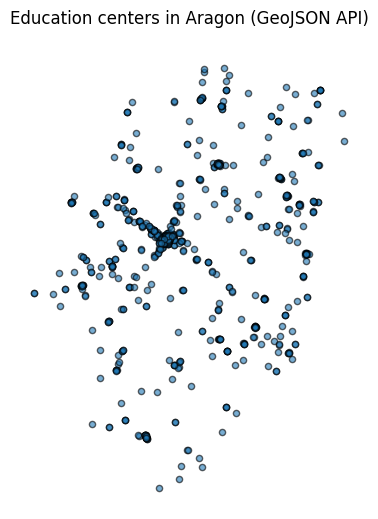

In [60]:
ax = gdf_geojson.plot(edgecolor="black", alpha=0.6, markersize=20)
ax.set_title("Education centers in Aragon (GeoJSON API)")
ax.set_axis_off()

In [61]:
gdf_geojson["naturaleza"]=="Público"

0       True
1       True
2       True
3      False
4       True
       ...  
891    False
892    False
893     True
894     True
895     True
Name: naturaleza, Length: 896, dtype: bool

### Cleaning and Filtering: Public Schools in Aragon

The dataset includes different types of centers. We will keep centers whose `naturaleza` value is public and whose type contains "Colegio Publico".

This builds a more realistic example of attribute selection.


In [62]:
gdf_colegios_publicos = gdf_geojson[
    (gdf_geojson["naturaleza"].str.contains("Público", case=False, na=False))
].copy()
# equivalent: gdf_geojson[gdf_geojson["naturaleza"]=="Público"].copy()

gdf_colegios_publicos[["nombre_cen", "tipo_centr", "naturaleza", "localidad", "geometry"]].head()

,nombre_cen,tipo_centr,naturaleza,localidad,geometry
0,C.P. María Moliner,Colegio Público,Público,Fraga,POINT (778171 4602434)
1,C.P. María Zambrano,Colegio Público,Público,Zaragoza,POINT (676837.84 4609567.9)
2,Centro Aragonés de Lenguas Extranjeras para la...,Centros de Innovación y Formación Educativa,Público,Zaragoza,POINT (677007 4617474)
4,C.P. José Camón Aznar,Colegio Público,Público,Zaragoza,POINT (673425.2 4613789.27)
6,C.P. Lucien Briet,Colegio Público,Público,Zaragoza,POINT (676939.96 4615480.51)


In [63]:
print("CRS:", gdf_colegios_publicos.crs)
print("Number of public schools:", len(gdf_colegios_publicos))
print("Number of represented localities:", gdf_colegios_publicos["localidad"].nunique())

CRS: EPSG:25830
Number of public schools: 672
Number of represented localities: 247


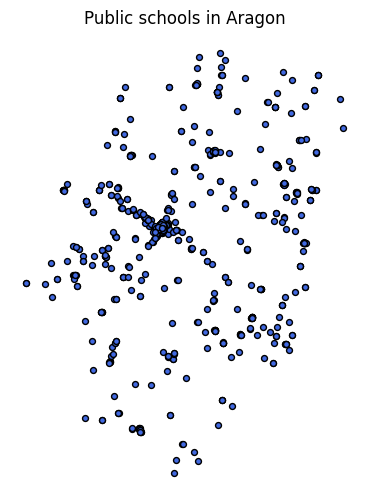

In [64]:
ax = gdf_colegios_publicos.plot(color="royalblue", edgecolor="black", markersize=18)
ax.set_title("Public schools in Aragon")
ax.set_axis_off()

### Quick Analysis by Locality

A common teaching question is: "which localities have the most public schools?"

We can answer it with a count by `localidad`.


In [65]:
top_localidades = (
    gdf_colegios_publicos.groupby("localidad")
    .size()
    .sort_values(ascending=False)
    .reset_index(name="num_colegios")
)

top_localidades.head(10)

,localidad,num_colegios
0,Zaragoza,143
1,Huesca,21
2,Teruel,17
3,Calatayud,11
4,Alcañiz,10
5,Fraga,10
6,Utebo,10
7,Jaca,10
8,Ejea De Los Caballeros,9
9,Barbastro,8


Text(0, 0.5, 'Number of schools')

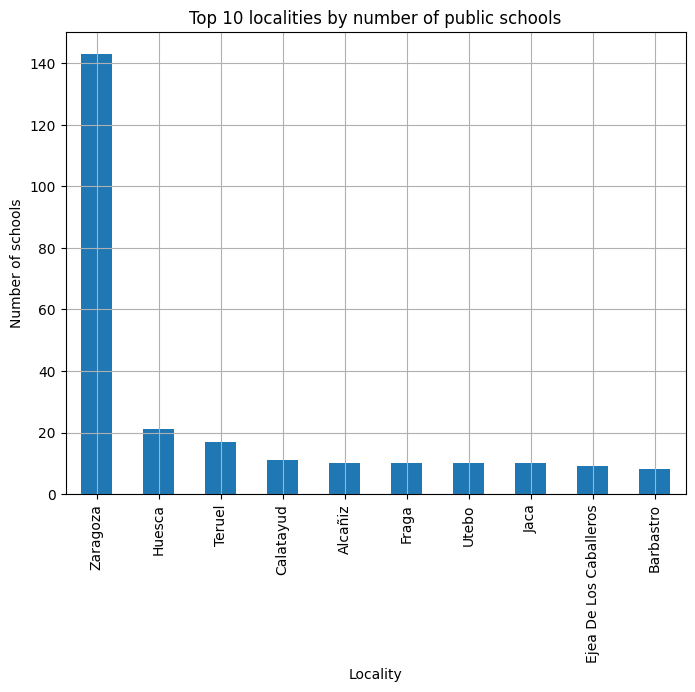

In [66]:
ax = top_localidades.head(10).plot.bar(x="localidad", y="num_colegios", legend=False)
ax.set_title("Top 10 localities by number of public schools")
ax.set_xlabel("Locality")
ax.set_ylabel("Number of schools")

### Export the Result to GeoJSON

Saving the public-school selection is useful for sharing results or using them in web viewers.


In [67]:
salida_geojson = "data/colegios_publicos_aragon.geojson"
gdf_colegios_publicos.to_file(salida_geojson, driver="GeoJSON")
print(f"Exported file: {salida_geojson}")

Exported file: data/colegios_publicos_aragon.geojson


## 3) Example B: Load Data from WFS (IDEE Transport)

Now we use a real WFS service from IDEE/IGN:

- Service: `https://servicios.idee.es/wfs-inspire/transportes`
- Operation: `request=GetFeature`
- Example layer: `tn-ro:RoadLink`

This service usually returns GML, which `geopandas` can read directly.


In [68]:
# Fixed WFS example with the requested layer: tn-ro:RoadLink
# To keep the example fast and readable, use a specific urban area.
# These coordinates are in EPSG:25830, the CRS of the schools.
colegios_zaragoza = gdf_colegios_publicos[
    gdf_colegios_publicos["localidad"].str.contains("Zaragoza", case=False, na=False)
].cx[670000:681000, 4609000:4620000].copy()

# Build a bbox from those schools, with a small margin in degrees.
xmin, ymin, xmax, ymax = colegios_zaragoza.to_crs(4326).total_bounds
margen = 0.01
bbox_escuelas = f"{xmin-margen},{ymin-margen},{xmax+margen},{ymax+margen},EPSG:4326"

url_wfs_aragon = (
    "https://servicios.idee.es/wfs-inspire/transportes?"
    "service=WFS&version=2.0.0&request=GetFeature&"
    "typeNames=tn-ro:RoadLink&count=3000&"
    f"srsName=EPSG:4326&bbox={bbox_escuelas}"
)

gdf_wfs_aragon = gpd.read_file(url_wfs_aragon)
print("Public schools in Zaragoza:", len(colegios_zaragoza))
print("WFS features loaded:", len(gdf_wfs_aragon))
print("BBox used:", bbox_escuelas)
gdf_wfs_aragon.head()

Public schools in Zaragoza: 139
WFS features loaded: 3000
BBox used: -0.9672309982273317,41.60486871844645,-0.8198184740622331,41.69937442956932,EPSG:4326


,gml_id,beginLifespanVersion,localId,namespace,endLifespanVersion,inNetwork,fictitious,validFrom,validTo,geometry
0,TN-RO_ROADLINK_VIAL_TR502979009451,2020-06-09T00:00:00,VIAL_TR502979009451,ES.SCNE.IGR-RT,None,None,True,None,None,"LINESTRING (-0.87427 41.61611, -0.87358 41.61686)"
1,TN-RO_ROADLINK_VIAL_TR502970041264,2021-01-20T00:00:00,VIAL_TR502970041264,ES.SCNE.IGR-RT,None,None,True,None,None,"LINESTRING (-0.88279 41.6135, -0.88277 41.61346)"
2,TN-RO_ROADLINK_VIAL_TR502970041318,2021-01-20T00:00:00,VIAL_TR502970041318,ES.SCNE.IGR-RT,None,None,True,None,None,"LINESTRING (-0.87862 41.6211, -0.87848 41.6207..."
3,TN-RO_ROADLINK_VIAL_TR502970041328,2021-01-20T00:00:00,VIAL_TR502970041328,ES.SCNE.IGR-RT,None,None,True,None,None,"LINESTRING (-0.8815 41.61753, -0.88142 41.6174..."
4,TN-RO_ROADLINK_VIAL_TR502970041258,2021-01-20T00:00:00,VIAL_TR502970041258,ES.SCNE.IGR-RT,None,None,True,None,None,"LINESTRING (-0.88194 41.61643, -0.88194 41.616..."


In [69]:
len(gdf_wfs_aragon) #! Look the number of entities. Are they all in Aragon?

3000

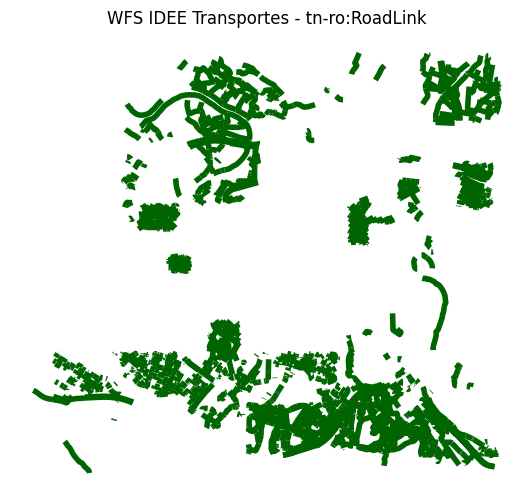

In [70]:
# Plot the data
ax = gdf_wfs_aragon.plot(color="darkgreen", linewidth=4)
ax.set_title("WFS IDEE Transportes - tn-ro:RoadLink")
ax.set_axis_off()
#! Look at the data


### Example of Operations on Vector Data

In this block, we combine layers, apply spatial operations, and calculate basic metrics for territorial analysis.


Public schools in the area: 139
Road segments in the area: 2993
Total network length (km): 351.7


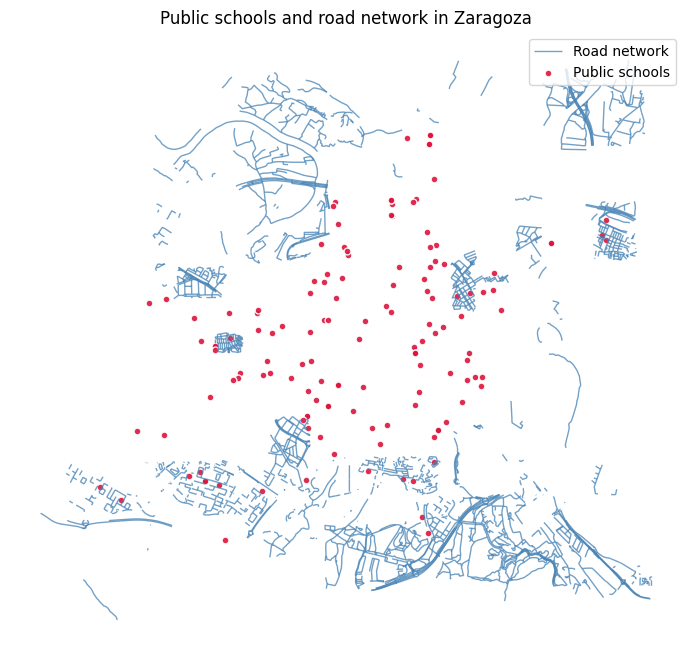

In [71]:
# C.2 Combine two GeoDataFrames: public schools + road network
# Use a metric CRS so distances and lengths are in meters.
crs_metrico = 25830

colegios_m = colegios_zaragoza.to_crs(epsg=crs_metrico)
red_m = gdf_wfs_aragon.to_crs(epsg=crs_metrico)

# Clean null or empty geometries before operating.
colegios_m = colegios_m[colegios_m.geometry.notna() & ~colegios_m.geometry.is_empty].copy()
red_m = red_m[red_m.geometry.notna() & ~red_m.geometry.is_empty].copy()

# Clip the network to the area occupied by the schools, with a 1 km margin.
xmin, ymin, xmax, ymax = colegios_m.total_bounds
margen_m = 1000
red_recortada = red_m.cx[xmin-margen_m:xmax+margen_m, ymin-margen_m:ymax+margen_m].copy()
red_recortada["longitud_m"] = red_recortada.geometry.length

print("Public schools in the area:", len(colegios_m))
print("Road segments in the area:", len(red_recortada))
print("Total network length (km):", round(red_recortada["longitud_m"].sum() / 1000, 2))

fig, ax = plt.subplots(figsize=(10, 8))

if red_recortada.empty:
    colegios_m.plot(ax=ax, color="crimson", markersize=18, alpha=0.9, label="Public schools")
    ax.set_title("Public schools in Zaragoza")
else:
    red_recortada.plot(ax=ax, color="steelblue", linewidth=1, alpha=0.75, label="Road network")
    colegios_m.plot(ax=ax, color="crimson", edgecolor="white", markersize=24, alpha=0.9, label="Public schools")
    ax.set_title("Public schools and road network in Zaragoza")

ax.legend()
ax.set_axis_off()

# Proposed Activities

1. Filter only centers from a specific province.
2. Reproject the data to EPSG:3857 and plot it again.
3. In the WFS, try another `typeNames` value from `GetCapabilities`.
4. Compare the column schema and geometry between GeoJSON and WFS.


In [ ]:
# Implement any proposed activity here